# Тестирование механизмов внимания на CIFAR-10

## Подготовка данных

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='../../data/cifar10', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root= '../../data/cifar10', train=False, download=True, transform=transform_test)


batch_size = 64
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

## Реализация модели

### Слои внимания

In [2]:
import torch
from build import build_attention
from config import FEMConfig

def get_fem_attention():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    B, T, D, H = batch_size, 5, 768, 8

    # Optional boolean mask (True=keep, False=pad)
    mask = torch.ones(B, T, dtype=torch.bool, device=device)
    mask[:, -3:] = torch.tensor([1, 0, 1], dtype=torch.bool, device=device)

    cfg = FEMConfig(
        n_embd=D, n_head=H,
        prior_type="softmax",        # "softmax" | "linear" | "gla" | "rnn_softmax" | "mamba"
        dropout=0.0, causal=True, bias=True,

        # Parameter budget (paper-aligned examples)
        fem_ratio=2/3,               # value path width (~ 2D/3)
        p_t_to_fem_ratio=2.0,        # total |Q|+|K| relative to fem_dim

        # Free-energy branch
        use_temperature=True,
        use_lse=True,
        use_outer_gate=True,

        # Extras (fully-parallel, CPU-safe)
        use_rope=True,
        use_conv=True,
        conv_hidden=64,
        conv_norm_first=True,
        conv_bidirectional=False,
    )

    return build_attention(cfg).to(device=device)

In [3]:
from build import _build_wave
from sequencelab.config import WaveConfig

def get_wave_attention():

    B, T, D, H = batch_size, 5, 768, 8

    cfg = WaveConfig(
        variant="gla_arma",  # or: "linear_arma", "gla_arma", "aft_arma"
        n_embd=D,
        n_head=H,
        dropout=0.0,
        ma_dropout=0.0,          # ARMA branch dropout
        bias=True,
        block_size=1024,         # only relevant for some softmax fallbacks
        decay=True               # used by GLA; safe to leave True
    )

    return _build_wave(cfg)

In [ ]:
from build import _build_zeros
from config import ZeroSConfig

def get_zeros_attention():
    B, T, D, H = batch_size, 5, 768, 4
    x = torch.randn(B, T, D)

    cfg = ZeroSConfig(
        n_embd=D, n_head=H,
        dropout=0.0, bias=True,
        block_size=T,            # RoPE length
        is_causal=True,
        init_params=True,        # GPT-2 style init for quick smoke tests
        init_n_layers=1,
        use_norm=True,
        use_associative=True
    )

    return _build_zeros(cfg)

## Реализация трансформера с кастомным attention'ом

In [5]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))  # Adjusted for [CLS] token

    def forward(self, x):
        return x + self.pos_embed

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)

    def forward(self, x):
        return self.attn(x, x, x)[0]

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, attention_type):
        super().__init__()
        if attention_type == "wave":
            self.attn = get_wave_attention()
        elif attention_type == "zeros":
            self.attn = get_zeros_attention()
        elif attention_type == "fem":
            self.attn = get_fem_attention()
        elif attention_type == "usual":
            self.attn = MultiHeadAttention(embed_dim, num_heads)
        else:
            raise RuntimeError(f"unknown attention_type: {attention_type}")
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # print(f"attention input shape : {self.norm1(x).shape}")
        x = x + self.attn(self.norm1(x))
        # print(f"attention output shape : {x.shape}")
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=16, num_classes=10, embed_dim=768, num_heads=8, depth=6, mlp_dim=1024, attention_type="fem"):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, (img_size // patch_size) ** 2)
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, attention_type=attention_type) for _ in range(depth)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        return self.mlp_head(x[:, 0])

## Обучение моделей

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
torch.cuda.empty_cache()

In [8]:
num_epochs = 10

In [9]:
import torch.optim as optim
from torchvision import datasets, transforms

model_wave = VisionTransformer(img_size=32, attention_type="wave").to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_wave.parameters(), lr=0.001)

losses_wave = []

# Training loop
for epoch in range(num_epochs):
    model_wave.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_wave(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader)}")
    losses_wave.append(running_loss/len(trainloader))

Epoch [1/10], Loss: 27.062652868383072
Epoch [2/10], Loss: 2.55632931405626
Epoch [3/10], Loss: 2.443118417964262
Epoch [4/10], Loss: 2.3637932081661566
Epoch [5/10], Loss: 2.3327967849228997
Epoch [6/10], Loss: 2.323211030582028
Epoch [7/10], Loss: 2.322613913079967
Epoch [8/10], Loss: 2.322018372738148
Epoch [9/10], Loss: 2.321811293092225
Epoch [10/10], Loss: 2.3574615238267747


In [ ]:
import torch.optim as optim
from torchvision import datasets, transforms

model_fem = VisionTransformer(img_size=32, attention_type="fem").to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_fem.parameters(), lr=0.001)

losses_fem = []

# Training loop
for epoch in range(num_epochs):  # Train for 5 epochs
    model_fem.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_fem(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader)}")
    losses_fem.append(running_loss/len(trainloader))

Epoch [1/5], Loss: 2.8555148013717377
Epoch [2/5], Loss: 2.3192551995787167
Epoch [3/5], Loss: 2.3151074663147595
Epoch [4/5], Loss: 2.31663390010824
Epoch [5/5], Loss: 2.3111907039456967
Epoch [6/5], Loss: 2.307632062136365
Epoch [7/5], Loss: 2.310207672436219
Epoch [8/5], Loss: 2.3078680818952866
Epoch [9/5], Loss: 31.372299617513672
Epoch [10/5], Loss: 2.400754366994209


In [ ]:
import torch.optim as optim
from torchvision import datasets, transforms

model_zeros = VisionTransformer(img_size=32, attention_type="zeros", num_heads=1, depth=1).to(device) # при других параметрах cuda OOM
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_zeros.parameters(), lr=0.001)

losses_zeros = []

# Training loop
for epoch in range(10):  # Train for 5 epochs
    model_zeros.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_zeros(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader)}")
    losses_zeros.append(running_loss/len(trainloader))

Epoch [1/10], Loss: 2.371906204296805
Epoch [2/10], Loss: 2.3365740696792408
Epoch [3/10], Loss: 2.3437934153525117
Epoch [4/10], Loss: 2.3331847337200817
Epoch [5/10], Loss: 2.3381192220751283
Epoch [6/10], Loss: 2.33536528687343
Epoch [7/10], Loss: 2.328750723158307
Epoch [8/10], Loss: 2.3267367215412658
Epoch [9/10], Loss: 2.327876691623112
Epoch [10/10], Loss: 2.328253876522679


In [ ]:
import torch.optim as optim
from torchvision import datasets, transforms

model_usual = VisionTransformer(img_size=32, attention_type="usual", num_heads=1, depth=1).to(device) # при других параметрах cuda OOM
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_usual.parameters(), lr=0.001)

losses_usual = []

# Training loop
for epoch in range(10):  # Train for 5 epochs
    model_usual.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_usual(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader)}")
    losses_usual.append(running_loss/len(trainloader))

Epoch [1/10], Loss: 2.400851773483979
Epoch [2/10], Loss: 2.3337055996555804
Epoch [3/10], Loss: 2.404679409378325
Epoch [4/10], Loss: 2.321069196057137
Epoch [5/10], Loss: 2.310584440255714
Epoch [6/10], Loss: 2.309928219641566
Epoch [7/10], Loss: 2.3072717104421554
Epoch [8/10], Loss: 2.3064978323934024
Epoch [9/10], Loss: 2.3058145216968664
Epoch [10/10], Loss: 2.3053831474860305


## Результаты обучения

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch

def compute_metrics(model, testloader, device=None):
    """
    Вычисляет метрики классификации на тестовых данных.

    Args:
        model (torch.nn.Module): обученная модель.
        testloader (torch.utils.data.DataLoader): DataLoader с тестовыми данными.
        device (str, optional): устройство для вычислений ('cuda' или 'cpu').
                                 Если None, определяется автоматически.

    Returns:
        dict: словарь с метриками ('accuracy', 'precision', 'recall', 'f1')
              и также матрицей ошибок ('confusion_matrix').
    """
    if device is None:
        device = 'cpu'
    
    model.eval()
    model.to(device)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Вычисление метрик
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1    }
    
    return metrics


In [ ]:
import pandas as pd

metrics_wave = compute_metrics(model_wave, testloader)
metrics_wave = pd.DataFrame([metrics_wave], index=['WAVE'])

metrics_zeros = compute_metrics(model_zeros, testloader)
metrics_zeros = pd.DataFrame([metrics_zeros], index=['ZEROS'])

metrics_fem = compute_metrics(model_fem, testloader)
metrics_fem = pd.DataFrame([metrics_fem], index=['FEM'])

metrics_usual = compute_metrics(model_usual, testloader)
metrics_usual = pd.DataFrame([metrics_usual], index=['Usual']).drop(columns=['confusion_matrix'])

In [ ]:
pd.concat([metrics_wave, metrics_zeros, metrics_fem, metrics_usual], axis=0)

,accuracy,precision,recall,f1
WAVE,0.1,0.01,0.1,0.018182
ZEROS,0.1,0.01,0.1,0.018182
FEM,0.1,0.01,0.1,0.018182


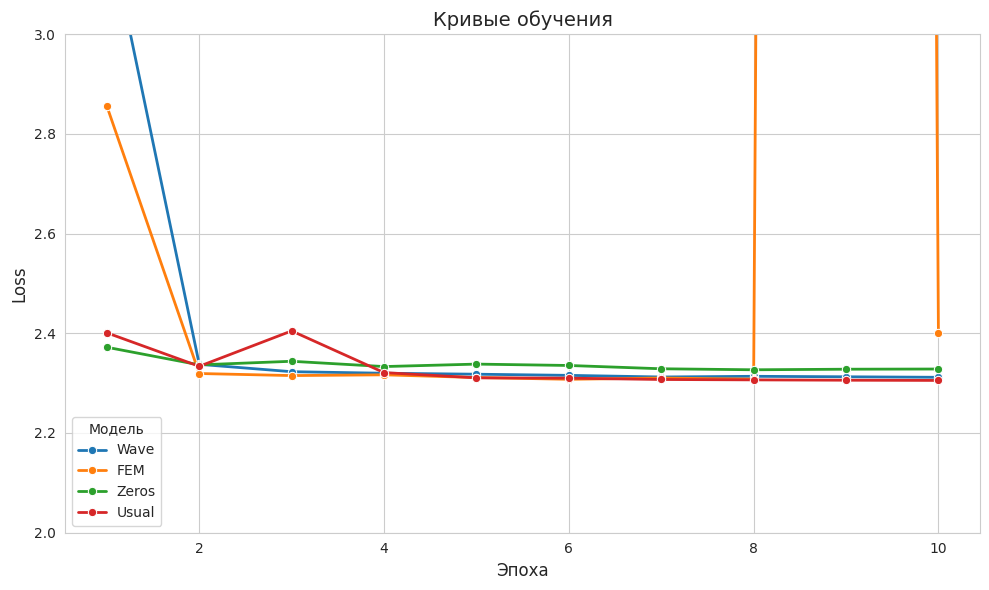

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def make_df(losses, name):
    epochs = list(range(1, len(losses) + 1))
    return pd.DataFrame({'Epoch': epochs, 'Loss': losses, 'Dataset': name})

df_wave = make_df(losses_wave, 'Wave')
df_fem = make_df(losses_fem, 'FEM')
df_zeros = make_df(losses_zeros, 'Zeros')
df_usual = make_df(losses_usual, 'Usual')

df_all = pd.concat([df_wave, df_fem, df_zeros, df_usual], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_all, x='Epoch', y='Loss', hue='Dataset', marker='o', markersize=6, linewidth=2)

plt.title('Кривые обучения', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.ylim(2, 3)
plt.legend(title='Модель')
plt.tight_layout()

plt.show()

## Итоги

В ходе эксперимента выяснилось, что приведенные механизмы внимания на CIFAR-10 не дают преимущества над обычным вниманием, так как:
* по скорости вычисления они медленнее
* по метрикам и значениям они практически такие же, как обычный attention

Кроме того допускаю, что результаты могут не отражать настояющую мощь данных attention'ов из-за
* малого количества эпох (всё уперлось в ресурсы моей видеокарты)
* плохо подобранных гиперпараметров обучения, параметров модели

В любом случае нужно отметить следующее:
* механизм внимания вполне себе интересен для рассмотрения и замены внутри архитектуры трансформера
* возможно, имеет смысл пробовать заменять и модифицировать другие составляющие трансформера